# SynapseMNIST 3D
von Yanni Alshoufi, Leo Breneis, Katharina Minihuber, Eros Klein, Melanie Dohr

Trainiert ein 3D-CNN auf dem SynapseMNIST3D Datensatz
(28x28x28 Voxel, binäre Klassifikation).

am 27.02.2026

## Load and explore the dataset

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC, Recall, Precision

DATA_DIR = "synapsemnist3d"

X_train = np.load(f"{DATA_DIR}/train_images.npy")
y_train = np.load(f"{DATA_DIR}/train_labels.npy")
X_val   = np.load(f"{DATA_DIR}/val_images.npy")
y_val   = np.load(f"{DATA_DIR}/val_labels.npy")
X_test  = np.load(f"{DATA_DIR}/test_images.npy")
y_test  = np.load(f"{DATA_DIR}/test_labels.npy")

print("=== Dataset Shapes ===")
print(f"Train:      images={X_train.shape}, labels={y_train.shape}")
print(f"Validation: images={X_val.shape},   labels={y_val.shape}")
print(f"Test:       images={X_test.shape},  labels={y_test.shape}")

=== Dataset Shapes ===
Train:      images=(1230, 28, 28, 28), labels=(1230, 1)
Validation: images=(177, 28, 28, 28),   labels=(177, 1)
Test:       images=(352, 28, 28, 28),  labels=(352, 1)


## Prepare the data

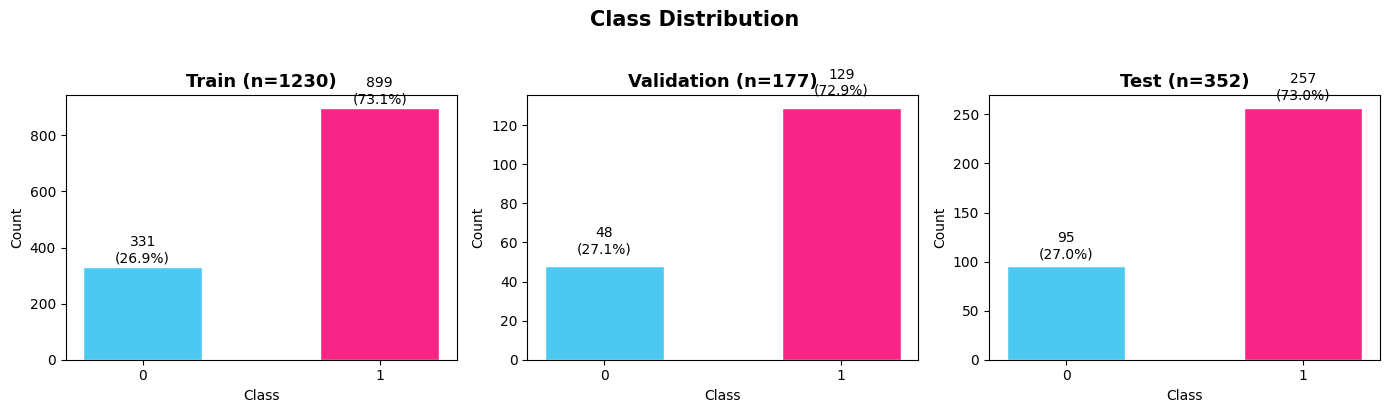

In [16]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Flatten labels from (N, 1) to (N,) then one-hot encode
y_train_flat = y_train.flatten()
y_val_flat   = y_val.flatten()
y_test_flat  = y_test.flatten()

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, labels, title in zip(axes, [y_train, y_val, y_test], ["Train", "Validation", "Test"]):
    unique, counts = np.unique(labels, return_counts=True)
    colors = ["#4cc9f0", "#f72585"]
    bars = ax.bar(unique, counts, color=colors[:len(unique)], edgecolor="white", width=0.5)
    ax.set_title(f"{title} (n={len(labels)})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticks(unique)
    for bar, count in zip(bars, counts):
        pct = count / len(labels) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.suptitle("Class Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

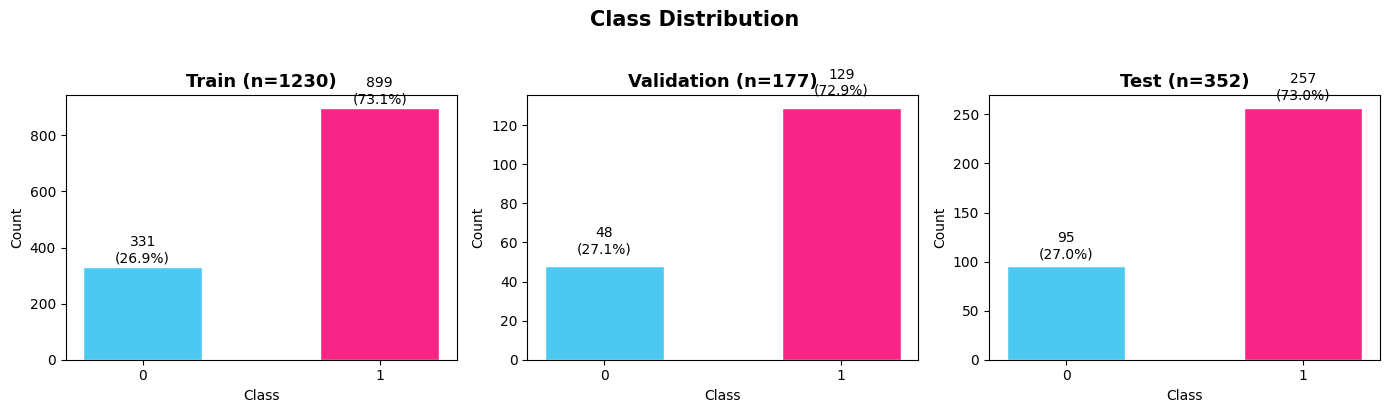

In [17]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, labels, title in zip(axes, [y_train, y_val, y_test], ["Train", "Validation", "Test"]):
    unique, counts = np.unique(labels, return_counts=True)
    colors = ["#4cc9f0", "#f72585"]
    bars = ax.bar(unique, counts, color=colors[:len(unique)], edgecolor="white", width=0.5)
    ax.set_title(f"{title} (n={len(labels)})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticks(unique)
    for bar, count in zip(bars, counts):
        pct = count / len(labels) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.suptitle("Class Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Build and train a 3D CNN

In [18]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train.flatten())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

Class weights: {0: 1.8580060422960725, 1: 0.6840934371523916}


In [19]:
# Add channel dimension: (N, 28, 28, 28) -> (N, 28, 28, 28, 1)
X_train_3d = X_train[..., np.newaxis]
X_val_3d   = X_val[..., np.newaxis]
X_test_3d  = X_test[..., np.newaxis]

cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 28, 1)),

    layers.Conv3D(32, (3, 3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling3D((2, 2, 2)),

    layers.Conv3D(64, (3, 3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling3D((2, 2, 2)),

    layers.GlobalAveragePooling3D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    restore_best_weights=True,
    patience=7,
)

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="auc"),
        Recall(name="recall"),
        Precision(name="precision"),
    ],
)

cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_3d, y_train_flat,
    validation_data=(X_val_3d, y_val_flat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict, 
    verbose=1,
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_4 (Conv3D)               │ (None, 28, 28, 28, 32) │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 28, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_4 (MaxPooling3D)  │ (None, 14, 14, 14, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 14, 14, 14, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 14, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_5 (MaxPooling3D)  │ (None, 7, 7, 7, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,865 (237.75 KB)

 Trainable params: 60,673 (237.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 37s 925ms/step - accuracy: 0.5073 - auc: 0.4864 - loss: 0.7969 - precision: 0.7250 - recall: 0.5250 - val_accuracy: 0.7288 - val_auc: 0.6505 - val_loss: 0.6585 - val_precision: 0.7288 - val_recall: 1.0000
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 36s 920ms/step - accuracy: 0.5789 - auc: 0.6161 - loss: 0.6725 - precision: 0.7856 - recall: 0.5829 - val_accuracy: 0.2712 - val_auc: 0.5450 - val_loss: 0.7649 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 37s 954ms/step - accuracy: 0.6691 - auc: 0.6511 - loss: 0.6592 - precision: 0.8022 - recall: 0.7264 - val_accuracy: 0.2712 - val_auc: 0.3987 - val_loss: 0.7738 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6520 - auc: 0.6895 - loss: 0.6378 - precision: 0.8322 - recall: 0.6563 - val_accuracy: 0.2712 - val_auc: 0.5984 - val_loss: 1.2338 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epo

## Evaluation

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.7301 - auc: 0.5420 - loss: 0.6592 - precision: 0.7301 - recall: 1.0000
Test – Loss: 0.6592, Accuracy: 0.7301, AUC: 0.5420, Recall: 1.0000, Precision: 0.7301


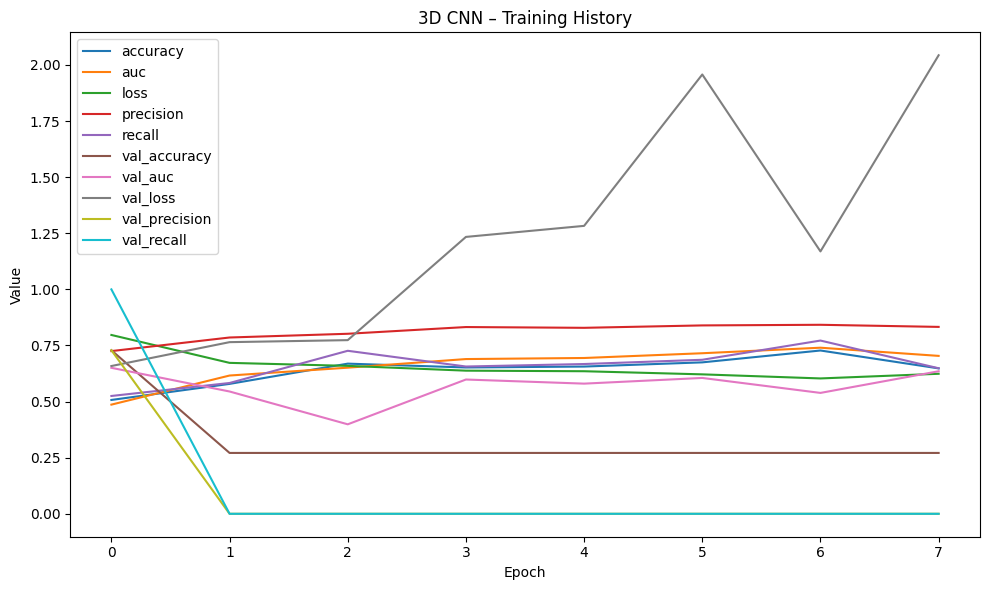

In [20]:
cnn_loss, cnn_acc, cnn_auc, cnn_recall, cnn_precision = cnn_model.evaluate(X_test_3d, y_test_flat, verbose=1)
print(f"Test – Loss: {cnn_loss:.4f}, Accuracy: {cnn_acc:.4f}, AUC: {cnn_auc:.4f}, Recall: {cnn_recall:.4f}, Precision: {cnn_precision:.4f}")

import pandas as pd

fig, ax = plt.subplots(figsize=(10, 6))
pd.DataFrame(cnn_history.history).plot(ax=ax)
ax.set_title("3D CNN – Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("cnn_3d_history.png", dpi=150)
plt.show()

## Save model artifacts for later single-image inference
This cell stores everything needed to reload the trained model and run predictions on one 3D image (28x28x28) later:
- Keras model file
- Inference metadata (input shape, normalization, threshold, class labels)
- Training history and final test metrics

In [ ]:
from pathlib import Path
import json
import pandas as pd
from tensorflow.keras.models import load_model

ARTIFACT_DIR = Path("model_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACT_DIR / "synapsemnist_3d_cnn.keras"
METADATA_PATH = ARTIFACT_DIR / "synapsemnist_3d_cnn_metadata.json"
HISTORY_PATH = ARTIFACT_DIR / "synapsemnist_3d_cnn_history.csv"

# 1) Save model weights + architecture in one file
cnn_model.save(MODEL_PATH)

# 2) Save training history for later analysis
pd.DataFrame(cnn_history.history).to_csv(HISTORY_PATH, index=False)

# 3) Save preprocessing + inference settings required for consistent single-image evaluation
model_metadata = {
    "model_path": str(MODEL_PATH),
    "input_shape": [28, 28, 28, 1],
    "expected_volume_shape": [28, 28, 28],
    "dtype": "float32",
    "normalization": {
        "method": "divide",
        "value": 255.0
    },
    "decision_threshold": 0.5,
    "class_names": {
        "0": "no_synapse",
        "1": "has_synapse"
    },
    "training": {
        "epochs_ran": len(cnn_history.history.get("loss", [])),
        "class_weight": {"0": float(class_weight_dict[0]), "1": float(class_weight_dict[1])}
    },
    "test_metrics": {
        "loss": float(cnn_loss),
        "accuracy": float(cnn_acc),
        "auc": float(cnn_auc),
        "recall": float(cnn_recall),
        "precision": float(cnn_precision)
    }
}

with METADATA_PATH.open("w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=2, ensure_ascii=True)

print(f"Saved model to: {MODEL_PATH}")
print(f"Saved metadata to: {METADATA_PATH}")
print(f"Saved history to: {HISTORY_PATH}")


def load_inference_bundle(artifact_dir="model_artifacts"):
    artifact_dir = Path(artifact_dir)
    metadata_path = artifact_dir / "synapsemnist_3d_cnn_metadata.json"
    with metadata_path.open("r", encoding="utf-8") as f:
        meta = json.load(f)
    model = load_model(meta["model_path"])
    return model, meta


def predict_single_volume(volume, model, meta):
    volume = np.asarray(volume, dtype=np.float32)

    expected_shape = tuple(meta["expected_volume_shape"])
    if volume.shape != expected_shape:
        raise ValueError(f"Expected volume shape {expected_shape}, got {volume.shape}")

    # Keep preprocessing identical to training
    norm_value = float(meta["normalization"]["value"])
    if volume.max() > 1.0:
        volume = volume / norm_value

    x = volume[np.newaxis, ..., np.newaxis]
    prob = float(model.predict(x, verbose=0)[0][0])
    threshold = float(meta["decision_threshold"])
    pred_idx = 1 if prob >= threshold else 0
    pred_label = meta["class_names"][str(pred_idx)]

    return {
        "probability_has_synapse": prob,
        "predicted_class_index": pred_idx,
        "predicted_label": pred_label
    }

# Example reload + single-image prediction:
reloaded_model, reloaded_meta = load_inference_bundle("model_artifacts")
single_result = predict_single_volume(X_test[0], reloaded_model, reloaded_meta)
print("Single-image inference example:", single_result)

Saved model to: model_artifacts/synapsemnist_3d_cnn.keras
Saved metadata to: model_artifacts/synapsemnist_3d_cnn_metadata.json
Saved history to: model_artifacts/synapsemnist_3d_cnn_history.csv
Single-image inference example: {'probability_class_1': 0.535674512386322, 'predicted_class_index': 1, 'predicted_label': 'has_synapse'}
